---
# Projekt z uczenia maszynowego 
---

In [ ]:
# Dla importu i scalania plików
import os
import zipfile
import xarray as xr
import pandas as pd
import glob

# Dla wykresów i matematyki
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
# Folder z danymi
DATA_DIR = r"D:\AGH\Uczenie maszynowe\Projekt"
os.chdir(DATA_DIR)

In [ ]:
zip_files = sorted(glob.glob("barcelona_era5_daily_*.nc"))

print("Znaleziono ZIP-udające-nc:", zip_files)

# Funkcja do przetwarzania jednego roku

In [ ]:

def process_year(zip_path):

    # Rok z nazwy pliku
    basename = os.path.basename(zip_path)
    year = basename.split("_")[-1].split(".")[0]

    # Folder tymczasowy dla danego roku
    out_dir = f"unzipped_{year}"
    os.makedirs(out_dir, exist_ok=True)

    # 2A: Rozpakuj ZIP-a
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(out_dir)

    # Znajdź pliki instant i accum
    nc_files = sorted(glob.glob(f"{out_dir}/*.nc"))

    instant_file = None
    accum_file = None

    for f in nc_files:
        if "instant" in f:
            instant_file = f
        elif "accum" in f:
            accum_file = f

    if instant_file is None or accum_file is None:
        raise ValueError(f"Brakuje plików instant/accum dla roku {year}")

    print(f"Przetwarzam rok {year}:")
    print(" - instant:", instant_file)
    print(" - accum:  ", accum_file)

    # 2B: Wczytaj oba strumienie
    ds_instant = xr.open_dataset(instant_file)
    ds_accum = xr.open_dataset(accum_file)

    # 2C: Scal oba strumienie
    ds_merged = xr.merge([ds_instant, ds_accum])

    # 2D: Zapisz scalony plik roczny
    merged_path = f"merged_{year}.nc"
    ds_merged.to_netcdf(merged_path)

    print(f" --> Zapisano {merged_path}")
    return merged_path

# Przetwarzanie wszystkich lat

In [ ]:
merged_files = []
for zf in zip_files:
    merged_files.append(process_year(zf))

# Wczytanie wszystkich datasetów i scelanie do jednego

In [ ]:
print("\nScalam lata w jeden dataset...")

ds_all = xr.open_mfdataset(merged_files, combine="by_coords")

# Konwersja temp. na stopnie C
ds_all["t2m"] = ds_all["t2m"] - 273.15
ds_all["d2m"] = ds_all["d2m"] - 273.15

# Zapisz finalny plik NetCDF
ds_all.to_netcdf("barcelona_era5_merged_all_years.nc")
print("Zapisano finalny plik: barcelona_era5_merged_all_years.nc")

# Zamieniamy DataSet na DataFrame

In [ ]:

# >> 5. Zamień dataset na DataFrame <<
df = ds_all.to_dataframe().reset_index()

print("\nGotowy DataFrame:")
print(df.head())
print("\nRozmiar DF:", df.shape)

# Wczytanie scalonego datasetu i konwertacja datasetu do dataframu

In [41]:
# 1) Wczytanie datasetu
ds_all = xr.open_dataset("barcelona_era5_merged_all_years.nc")
# 2) Sprawdzenie wymiarów
ds_all.dims

# 3) Zmiana nazwy zmiennej która odpowiada za czas
ds_all = ds_all.rename({"valid_time": "time"})
ds_all.dims

# 4) Usunięcie zmiennych technicznych
ds_all = ds_all.drop_vars(["expver", "number"], errors="ignore")

In [42]:
# Zamiana Datasetu na DataFrame
df = (
    ds_all
    .mean(dim=("latitude", "longitude"))
    .to_dataframe()
    .reset_index()
)


In [43]:
df.head(5)


,time,t2m,d2m,u10,v10,sp,tp,ssrd,strd
0,1994-01-01 12:00:00,12.225128,3.114227,6.357720,-0.817762,100329.039062,3.814736e-07,1.424301e+06,9.831812e+05
1,1994-01-02 12:00:00,12.619069,6.671600,5.014694,-0.046143,99972.835938,0.000000e+00,1.184077e+06,1.098960e+06
2,1994-01-03 12:00:00,14.533478,8.482783,5.347303,1.412481,99509.062500,0.000000e+00,1.499868e+06,1.011549e+06
3,1994-01-04 12:00:00,13.439799,7.359609,6.193847,0.053555,99267.289062,1.430526e-07,8.152058e+05,1.180333e+06
4,1994-01-05 12:00:00,11.650737,3.463125,5.333937,2.098606,99561.414062,0.000000e+00,1.480580e+06,9.529411e+05


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11323 entries, 0 to 11322
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    11323 non-null  datetime64[ns]
 1   t2m     11323 non-null  float32       
 2   d2m     11323 non-null  float32       
 3   u10     11323 non-null  float32       
 4   v10     11323 non-null  float32       
 5   sp      11323 non-null  float32       
 6   tp      11323 non-null  float32       
 7   ssrd    11323 non-null  float32       
 8   strd    11323 non-null  float32       
dtypes: datetime64[ns](1), float32(8)
memory usage: 442.4 KB


In [45]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
time,11323,2009-07-02 12:00:00,1994-01-01 12:00:00,2001-10-02 00:00:00,2009-07-02 12:00:00,2017-04-02 00:00:00,2024-12-31 12:00:00,NaN
t2m,11323.0,18.283804,2.681285,13.594978,17.795797,23.190559,33.034534,5.707871
d2m,11323.0,11.73614,-11.665721,7.452723,11.72701,16.719833,23.995712,5.870052
u10,11323.0,0.295526,-14.082494,-1.594654,0.440557,2.133332,14.764318,3.04659
v10,11323.0,1.201914,-10.763801,-0.16733,1.489053,2.842023,10.533189,2.266268
sp,11323.0,99889.671875,96768.164062,99523.78125,99909.648438,100290.363281,102038.1875,679.92688
tp,11323.0,0.000084,0.0,0.0,0.000001,0.000032,0.008197,0.000319
ssrd,11323.0,2173950.0,119598.273438,1532405.1875,2201506.25,2872196.0,3582212.25,784070.8125
strd,11323.0,1197331.375,719113.5625,1079393.25,1203585.75,1319520.125,1550875.875,148954.53125


## Info o ERA5
Dane temperatury wykorzystane w analizie pochodzą z reanalizy ERA5, która stanowi rekonstrukcję stanu atmosfery opartą na asimilacji szerokiego spektrum obserwacji (satelitarnych, naziemnych, radiosondowych) z wykorzystaniem numerycznego modelu atmosfery ECMWF. Wartości temperatury 2 m nie są bezpośrednimi pomiarami pojedynczych czujników, lecz najlepszym estymatem pola temperatury w regularnej siatce o rozdzielczości 0.25° × 0.25°. Zastosowane dane reprezentują klimat regionu, a nie warunki mikroklimatyczne miasta.


## Morze? 
Analizowany obszar obejmuje zarówno fragment lądu, jak i przyległą część Morza Śródziemnego. Jest to uzasadnione ze względu na silny wpływ warunków morskich na klimat Barcelony, w szczególności na temperaturę powietrza, wilgotność oraz cyrkulację lokalną. Dane ERA5 reprezentują zatem klimat regionu Barcelony, a nie wyłącznie warunki miejskie w sensie mikroklimatycznym.

# Temat projektu: 
## Analiza zmian sezonowości i ekstremów klimatycznych w regionie Barcelony w latach 1994-2024 na podstawie danych ERA5

# Główne pytanie badawcze: 
## Jak zmienia się sezonowość klimatu w regionie Barcelony w ostatnich trzech dekadach i jakie implikacje wynikają z tych zmian dla przyszłych warunków klimatycznych?

# Hipotezy badawcze: 
1. Sezon letni w regionie Barcelony uległ wydłużeniu w analizowanym okresie.
2. Średnia temperatura lata wzrosła istotnie szybciej niż temperatura zimy.
3. Wzrosła liczba dni ekstremalnie ciepłych oraz zmniejszyła się liczba dni chłodnych.
4. Zmienność sezonowa opadów uległa zmianie (suchsze lata, intensywniejsze epizody opadowe).
5. Na podstawie cech sezonowych możliwe jest prognozowanie przyszłych wartości wybranych wskaźników klimatycznych z użyciem metod ML.

## ETAP 0 - Dane i przygotowanie do analizy

### 0.1) Krótka inspekcja danych

In [46]:
df.head()

,time,t2m,d2m,u10,v10,sp,tp,ssrd,strd
0,1994-01-01 12:00:00,12.225128,3.114227,6.357720,-0.817762,100329.039062,3.814736e-07,1.424301e+06,9.831812e+05
1,1994-01-02 12:00:00,12.619069,6.671600,5.014694,-0.046143,99972.835938,0.000000e+00,1.184077e+06,1.098960e+06
2,1994-01-03 12:00:00,14.533478,8.482783,5.347303,1.412481,99509.062500,0.000000e+00,1.499868e+06,1.011549e+06
3,1994-01-04 12:00:00,13.439799,7.359609,6.193847,0.053555,99267.289062,1.430526e-07,8.152058e+05,1.180333e+06
4,1994-01-05 12:00:00,11.650737,3.463125,5.333937,2.098606,99561.414062,0.000000e+00,1.480580e+06,9.529411e+05


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11323 entries, 0 to 11322
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    11323 non-null  datetime64[ns]
 1   t2m     11323 non-null  float32       
 2   d2m     11323 non-null  float32       
 3   u10     11323 non-null  float32       
 4   v10     11323 non-null  float32       
 5   sp      11323 non-null  float32       
 6   tp      11323 non-null  float32       
 7   ssrd    11323 non-null  float32       
 8   strd    11323 non-null  float32       
dtypes: datetime64[ns](1), float32(8)
memory usage: 442.4 KB


In [48]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
time,11323,2009-07-02 12:00:00,1994-01-01 12:00:00,2001-10-02 00:00:00,2009-07-02 12:00:00,2017-04-02 00:00:00,2024-12-31 12:00:00,NaN
t2m,11323.0,18.283804,2.681285,13.594978,17.795797,23.190559,33.034534,5.707871
d2m,11323.0,11.73614,-11.665721,7.452723,11.72701,16.719833,23.995712,5.870052
u10,11323.0,0.295526,-14.082494,-1.594654,0.440557,2.133332,14.764318,3.04659
v10,11323.0,1.201914,-10.763801,-0.16733,1.489053,2.842023,10.533189,2.266268
sp,11323.0,99889.671875,96768.164062,99523.78125,99909.648438,100290.363281,102038.1875,679.92688
tp,11323.0,0.000084,0.0,0.0,0.000001,0.000032,0.008197,0.000319
ssrd,11323.0,2173950.0,119598.273438,1532405.1875,2201506.25,2872196.0,3582212.25,784070.8125
strd,11323.0,1197331.375,719113.5625,1079393.25,1203585.75,1319520.125,1550875.875,148954.53125


In [49]:
df["time"].min(), df["time"].max()

(Timestamp('1994-01-01 12:00:00'), Timestamp('2024-12-31 12:00:00'))

### 0.2) Konwersja jednostek

In [50]:
# opady: m -> mm
df["tp_mm"] = df["tp"] * 1000
# prędkość wiatru 
df["wind_speed"] = (df["u10"]**2 + df["v10"]**2)**0.5
# ciśnienie: Pa -> hPa
df["sp_hpa"] = df["sp"] / 100

### 0.3) Cechy czasowe (kolumny pomocnicze)

In [51]:
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day

In [52]:
# Sezony meteorologiczne
def season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else: 
        return "SON"

df["season"] = df["month"].apply(season)

In [53]:
df["season"].value_counts(normalize=True)

season
MAM    0.251877
JJA    0.251877
SON    0.249139
DJF    0.247108
Name: proportion, dtype: float64

### 0.4) Sprawdzenie braków danych

In [54]:
df.isna().sum()

time          0
t2m           0
d2m           0
u10           0
v10           0
sp            0
tp            0
ssrd          0
strd          0
tp_mm         0
wind_speed    0
sp_hpa        0
year          0
month         0
day           0
season        0
dtype: int64

### 0.5) Ostateczny zbiór roboczy

In [55]:
df_climate = df[["time", "year", "month", "season", "t2m", "d2m", "tp_mm", "wind_speed", "sp_hpa", "ssrd", "strd"]]

# Wnioski

Dane i metody

W analizie wykorzystano dane z reanalizy ERA5 udostępnianej przez Copernicus Climate Change Service (C3S). ERA5 stanowi globalną rekonstrukcję stanu atmosfery, opartą na asimilacji obserwacji satelitarnych, naziemnych oraz radiosondowych z wykorzystaniem numerycznego modelu atmosfery ECMWF.

Analiza obejmuje okres od 1994 do 2024 roku i opiera się na danych dziennych, reprezentujących wartości z godziny 12:00 UTC. Wybrany obszar obejmuje region Barcelony, zdefiniowany jako prostokątny obszar geograficzny obejmujący sześć komórek siatki ERA5 o rozdzielczości 0.25° × 0.25°. W celu uzyskania reprezentatywnej serii czasowej klimatu regionu zastosowano uśrednienie przestrzenne wartości zmiennych.

Do analizy wybrano kluczowe zmienne klimatyczne: temperaturę powietrza na wysokości 2 m, temperaturę punktu rosy, opady całkowite, prędkość wiatru, ciśnienie przy powierzchni oraz promieniowanie słoneczne i długofalowe. Dane zostały przekształcone do powszechnie stosowanych jednostek (°C, mm, hPa), a następnie uzupełnione o cechy czasowe, takie jak rok, miesiąc oraz sezon meteorologiczny.

Zastosowane dane charakteryzują się jednorodnością czasową i przestrzenną, co umożliwia analizę długoterminowych trendów oraz zmian sezonowości. Jednocześnie należy zaznaczyć, że rozdzielczość przestrzenna danych ERA5 nie pozwala na analizę mikroklimatu miejskiego, a uzyskane wyniki odnoszą się do warunków klimatycznych regionu, a nie pojedynczych punktów pomiarowych.

## ETAP 1 - Analiza bazowej sezonowości klimatu (EDA)

### 1.1) Średnia miesięczna temperatura (klimatologia miesięczna)

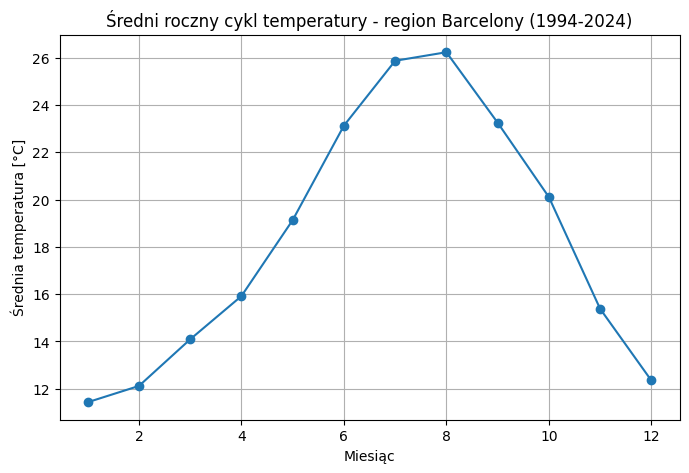

In [56]:
monthly_temp = (
    df_climate
    .groupby("month")["t2m"]
    .mean()
)
monthly_temp

# Wykres
plt.figure(figsize=(8,5))
monthly_temp.plot(marker="o")
plt.xlabel("Miesiąc")
plt.ylabel("Średnia temperatura [°C]")
plt.title("Średni roczny cykl temperatury - region Barcelony (1994-2024)")
plt.grid(True)
plt.show()

### 1.2) Średnie miesięczne opady

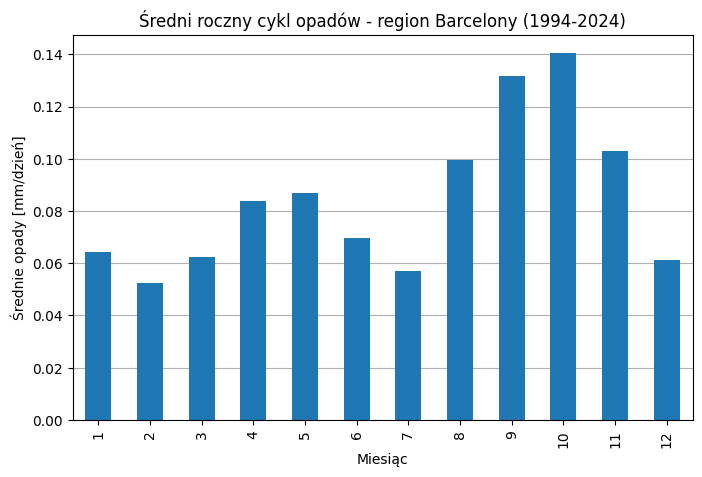

In [57]:
avg_monthly_precip = (
    df_climate
    .groupby("month")["tp_mm"]
    .mean()
)
avg_monthly_precip

# Wykres
plt.figure(figsize=(8,5))
avg_monthly_precip.plot(kind="bar")
ax = plt.gca()
ax.set_axisbelow(True)
plt.xlabel("Miesiąc")
plt.ylabel("Średnie opady [mm/dzień]")
plt.title("Średni roczny cykl opadów - region Barcelony (1994-2024)")
plt.grid(axis="y")
plt.show()

### 1.3) Promieniowanie słoneczne (ssrd)

In [58]:
df_climate["ssrd_mj"] = df_climate["ssrd"] / 1e6

C:\Users\asus2\AppData\Local\Temp\ipykernel_6028\476775311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_climate["ssrd_mj"] = df_climate["ssrd"] / 1e6


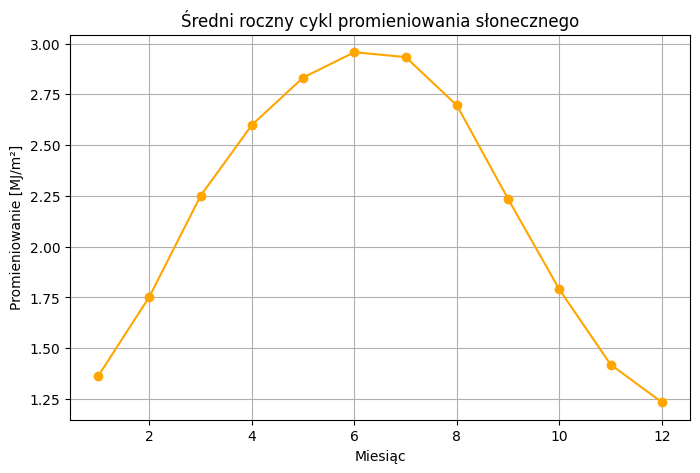

In [59]:
avg_monthly_ssrd = (
    df_climate
    .groupby("month")["ssrd_mj"]
    .mean()
)
avg_monthly_ssrd

# Wykres
plt.figure(figsize=(8,5))
avg_monthly_ssrd.plot(marker="o", color="orange")
plt.xlabel("Miesiąc")
plt.ylabel("Promieniowanie [MJ/m²]")
plt.title("Średni roczny cykl promieniowania słonecznego")
plt.grid(True)
plt.show()

### 1.4) Heatmapa: temperatura (rok x miesiąc)

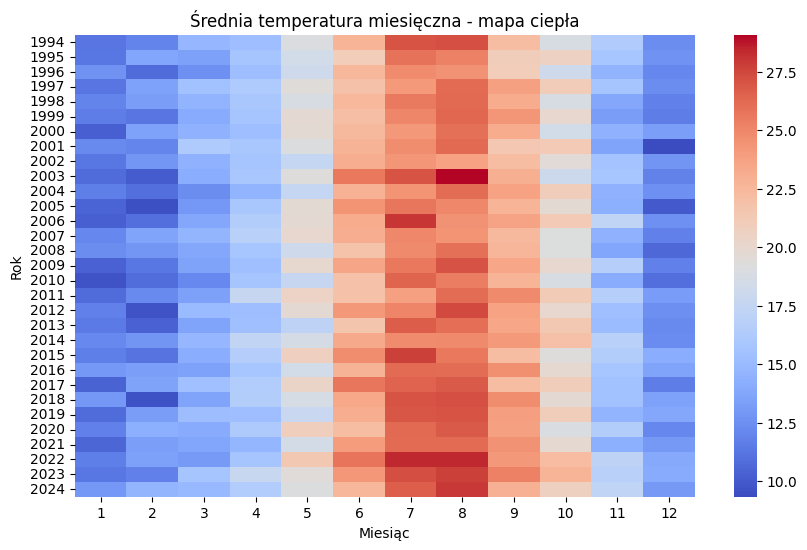

In [60]:
pivot_temp = df_climate.pivot_table(
    values="t2m",
    index="year",
    columns="month",
    aggfunc="mean"
)
pivot_temp

plt.figure(figsize=(10,6))
sns.heatmap(pivot_temp, cmap="coolwarm")
plt.xlabel("Miesiąc")
plt.ylabel("Rok")
plt.title("Średnia temperatura miesięczna - mapa ciepła")
plt.show()


# Wnioski


W pierwszym etapie analizy przeprowadzono eksploracyjną ocenę bazowej sezonowości klimatu regionu Barcelony. Średni roczny cykl temperatury charakteryzuje się wyraźnym minimum w miesiącach zimowych oraz maksimum w okresie letnim, z amplitudą sezonową typową dla klimatu śródziemnomorskiego.

Analiza opadów wskazuje na silną sezonowość, z wyraźnie suchym okresem letnim oraz zwiększoną sumą opadów w miesiącach jesiennych. Taki rozkład opadów jest charakterystyczny dla regionów położonych nad Morzem Śródziemnym i stanowi istotne tło dla dalszej analizy zmian klimatycznych.

Sezonowy przebieg promieniowania słonecznego wykazuje silną zmienność roczną, z maksimum w miesiącach letnich i minimum zimą, co odzwierciedla astronomiczne uwarunkowania dopływu energii słonecznej. Uzyskane wyniki stanowią punkt odniesienia dla dalszej analizy zmian sezonowości i trendów długoterminowych.

## ETAP 2 - Zmiany sezonowości w czasie

### 2.1) Średnia temperatura sezonowa w czasie

In [61]:
seasonal_temp = (
    df_climate
    .groupby(["year", "season"])["t2m"]
    .mean()
    .reset_index()
)

seasonal_temp.head()

,year,season,t2m
0,1994,DJF,11.833445
1,1994,JJA,25.665726
2,1994,MAM,16.345276
3,1994,SON,19.095808
4,1995,DJF,12.473289


### 2.2) Wykres: temperatura sezonowa w czasie

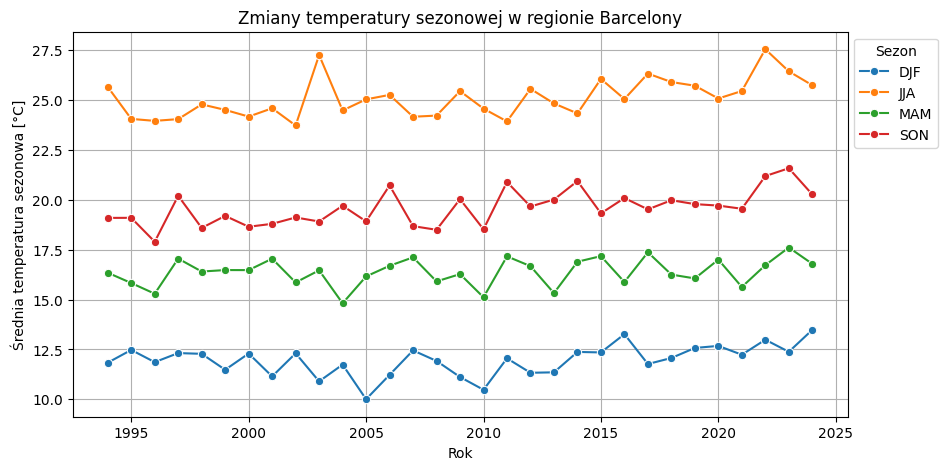

In [62]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=seasonal_temp,
    x="year",
    y="t2m",
    hue="season",
    marker="o"
)

plt.xlabel("Rok")
plt.ylabel("Średnia temperatura sezonowa [°C]")
plt.title("Zmiany temperatury sezonowej w regionie Barcelony")
plt.legend(title="Sezon", bbox_to_anchor=(1, 1),
    loc="upper left")
plt.grid(True)
plt.show()

### 2.3) Trend liniowy dla każdego sezonu

In [63]:
from scipy.stats import linregress

trend_results = []
for season in seasonal_temp["season"].unique():
    data = seasonal_temp[seasonal_temp["season"] == season]
    slope, intercept, r, p, stderr = linregress(data["year"], data["t2m"])
    trend_results.append({
        "season": season,
        "trend_C_per_year": slope,
        "trend_C_per_decade": slope*10,
        "p-value": p
    })

trend_df = pd.DataFrame(trend_results)
trend_df

,season,trend_C_per_year,trend_C_per_decade,p-value
0,DJF,0.031201,0.312011,0.040982
1,JJA,0.058266,0.582663,0.001570
2,MAM,0.018886,0.188861,0.180464
3,SON,0.058295,0.582955,0.000362


Trend dla MAM nie jest istotny, p-value = 0.18

### 2.4) Porównanie dwóch okresów (wczesny vs późny)

C:\Users\asus2\AppData\Local\Temp\ipykernel_6028\216410451.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_climate["period"] = np.where(


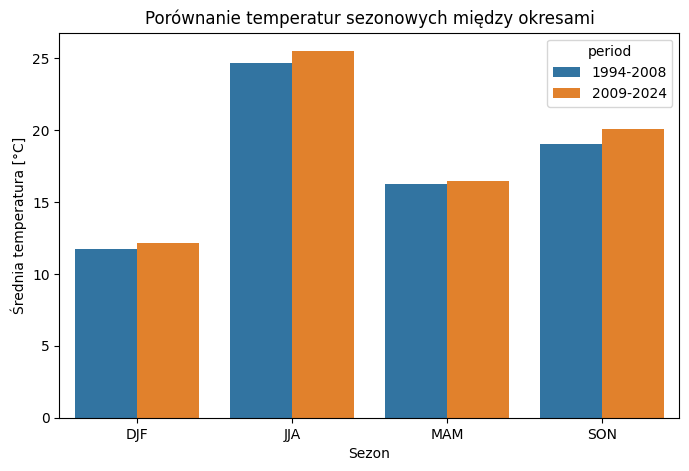

In [64]:
df_climate["period"] = np.where(
    df_climate["year"] <= 2008,
    "1994-2008",
    "2009-2024"
)

seasonal_period = (
    df_climate
    .groupby(["period", "season"])["t2m"]
    .mean()
    .reset_index()
)

# Wykres
plt.figure(figsize=(8,5))
sns.barplot(
    data=seasonal_period,
    x="season",
    y="t2m",
    hue="period"
)
plt.xlabel("Sezon")
plt.ylabel("Średnia temperatura [°C]")
plt.title("Porównanie temperatur sezonowych między okresami")
plt.show()

### 2.5) Amplituda sezonowa (lato-zima)

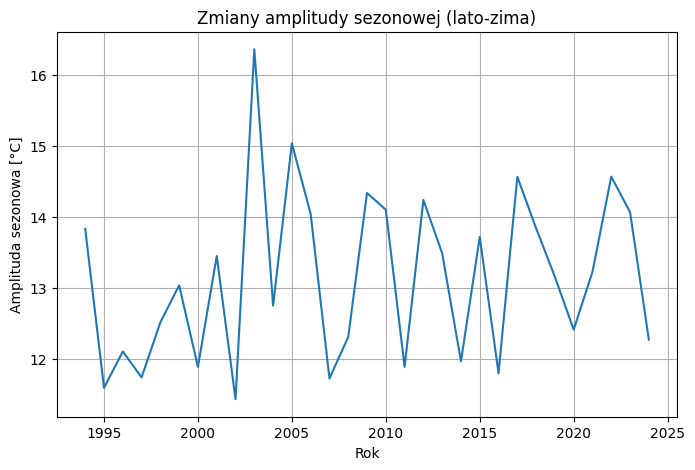

In [65]:
seasonal_wide = seasonal_temp.pivot(
    index="year",
    columns="season",
    values="t2m"
)

seasonal_wide["amplitude"] = (
    seasonal_wide["JJA"] - seasonal_wide["DJF"]
)

plt.figure(figsize=(8,5))
plt.plot(seasonal_wide.index, seasonal_wide["amplitude"])
plt.xlabel("Rok")
plt.ylabel("Amplituda sezonowa [°C]")
plt.title("Zmiany amplitudy sezonowej (lato-zima)")
plt.grid(True)
plt.show()


## Wnioski

W kolejnym etapie analizy zbadano zmiany sezonowych wartości temperatury powietrza w regionnie Barcelony w okresie 1994-2024. Analiza wukazała występowanie dodatnich trendów temperatury w większości sezonów, jednak tempo oraz istotność statystyczna tych zmian różnią się pomiędzy porami roku.

Najsilniejszy i statystycznie istotny wzrost temperatury zaobserwowano w sezonach letnim (JJA) oraz jesiennym (SON), dla których tempo ocieplenia wyniosło około 0.58°C na dekadę (p < 0.01). W sezonie zimowym (DJF) również występuje dodatni trend temperatury, jednak jego tempo jest niższe (około 0.31°C na dekadę) i charaktyrezuje się mniejszą istotnością statystyczną.

W przypadku sezonu wiosennego (MAM) zaobserwowany trend wzrostowy nie osiągnął istotności statystycznej (p=0.18), co wskazuje na większą zmienność międzyroczną oraz brak jednoznacznego długoterminiowego ocieplenia w tym sezonie w analizowanym okresie.

Porównanie średnich temperatur sezonowych pomiędzy dwoma podokresami (1994-2008 oraz 2009-2024) potwierdza wyraźne ocieplenie w sezonie letnim i jesiennym, podczas gdy zmiany w sezonie wiosennym są relatywnie niewielkie. Analiza amplitudy sezonowej (różnicy temperatury między latem a zimą) nie wskazuje na jednoznaczny trend monotoniczny, jednak obserwowane wahania sugerują okresowe nasilanie kontrastu termicznego pomiędzy porami roku.

Uzyskane wyniki wskazują, że zmiany sezonowości temperatury w regionie Barcelony są zdominowane przez intensyfikację ocieplenia w ciepłej połowie roku, co stanowi istotny kontekst dla dalszej analizy długości sezonów letnich oraz częstości występowania ekstremalnie wysokich temperatur.

## Hipotezy

Hipoteza 2
Średnia temperatura lata wzrosła szybciej niż temperatura zimy
POTWIERDZONA

(nowa) Hipoteza o jednolitym wzroście we wszystkich sezonach
NIE POTWIERDZONA

## ETAP 3 - Długość sezonów i przesunięcie lata

### 3.0) Definicje

Zdefiniujemy jawnie co to jest lato: 

1. dzień letni: T$_{2m}$ > 20°C;

2. dzień upalny: T$_{2m}$ > 30°C.

### 3.1) Liczba dni letnich i upalnych w roku

C:\Users\asus2\AppData\Local\Temp\ipykernel_6028\512715336.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_climate["is_summer_day"] = df_climate["t2m"] > 20
C:\Users\asus2\AppData\Local\Temp\ipykernel_6028\512715336.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_climate["is_hot_day"] = df_climate["t2m"] > 30


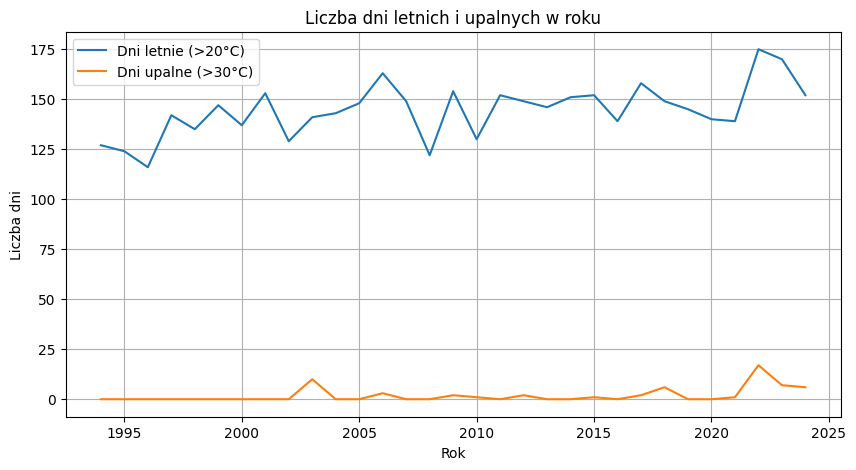

In [66]:
df_climate["is_summer_day"] = df_climate["t2m"] > 20
df_climate["is_hot_day"] = df_climate["t2m"] > 30

summer_days_yearly = (
    df_climate
    .groupby("year")[["is_summer_day", "is_hot_day"]]
    .sum()
    .reset_index()
)

#summer_days_yearly

# Wykres
plt.figure(figsize=(10,5))
plt.plot(summer_days_yearly["year"], summer_days_yearly["is_summer_day"], label="Dni letnie (>20°C)")
plt.plot(summer_days_yearly["year"], summer_days_yearly["is_hot_day"], label="Dni upalne (>30°C)")
plt.xlabel("Rok")
plt.ylabel("Liczba dni")
plt.title("Liczba dni letnich i upalnych w roku")
plt.legend()
plt.grid(True)
plt.show()



### 3.2) Początek i koniec sezonu letniego

Początek lata - pierwszy dzień z T > 20°C.
Koniec lata - ostatni dzień z T > 20°C.

In [67]:
def summer_bounds(group):
    summer_days = group[group["t2m"] > 20]
    if summer_days.empty:
        return pd.Series({"start": None, "end": None, "length": 0})
    return pd.Series({
        "start": summer_days["time"].min(),
        "end": summer_days["time"].max(),
        "length": len(summer_days)
    })

summer_season = (
    df_climate
    .groupby("year")
    .apply(summer_bounds)
    .reset_index()
    
)

summer_season["start_doy"] = summer_season["start"].dt.dayofyear
summer_season["end_doy"] = summer_season["end"].dt.dayofyear

C:\Users\asus2\AppData\Local\Temp\ipykernel_6028\624889909.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summer_bounds)


### 3.3) Czy lato zaczyna się wcześniej?

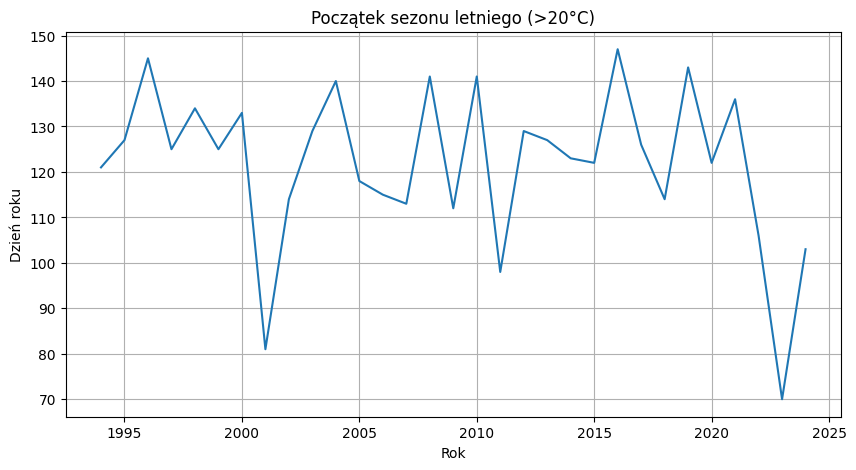

In [68]:
# Wykres
plt.figure(figsize=(10,5))
plt.plot(summer_season["year"], summer_season["start_doy"])
plt.xlabel("Rok")
plt.ylabel("Dzień roku")
plt.title("Początek sezonu letniego (>20°C)")
plt.grid(True)
plt.show()

### 3.4) Czy lato kończy się później?

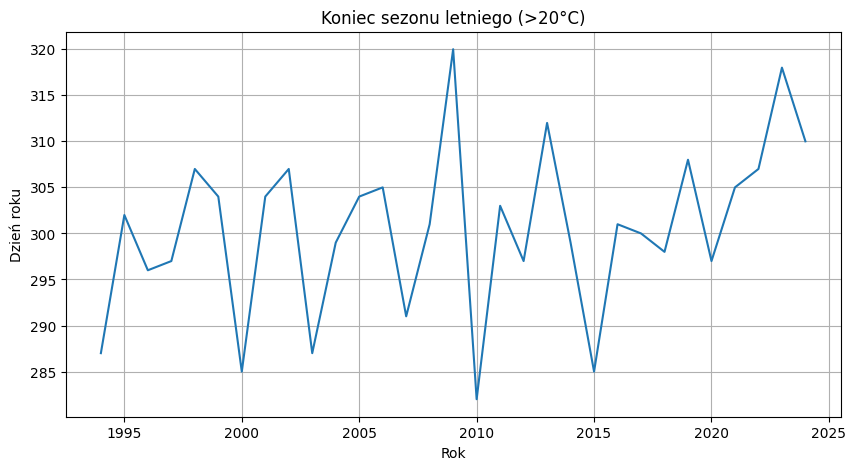

In [69]:
plt.figure(figsize=(10,5))
plt.plot(summer_season["year"], summer_season["end_doy"])
plt.xlabel("Rok")
plt.ylabel("Dzień roku")
plt.title("Koniec sezonu letniego (>20°C)")
plt.grid(True)
plt.show()

### 3.5) Długość sezonu letniego

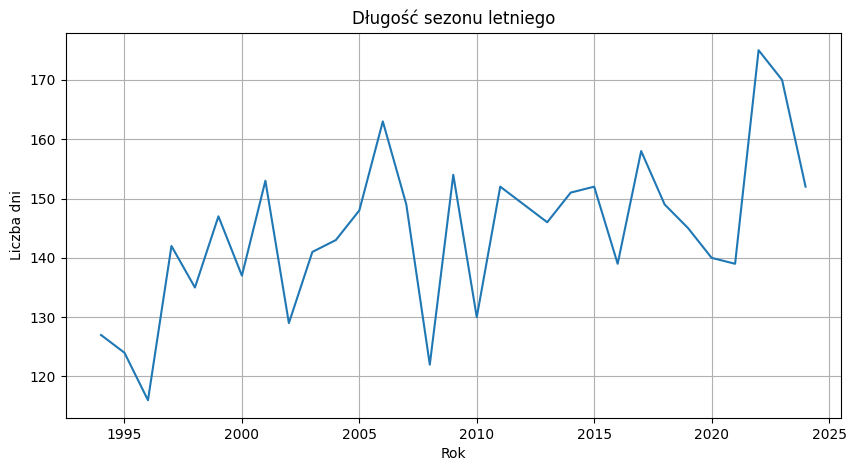

In [70]:
plt.figure(figsize=(10, 5))
plt.plot(summer_season["year"], summer_season["length"])
plt.xlabel("Rok")
plt.ylabel("Liczba dni")
plt.title("Długość sezonu letniego")
plt.grid(True)
plt.show()

## Wnioski

Analiza wykazała istotne zmiany sezonowości klimatu w regionie Barcelony, przejawiające się wyraźnym wzrostem liczby dni letnich oraz coraz częstrzym występowaniem dni ekstermalnie ciepłych. W ostatnich latach obserwuje się również tendencję do późniejszego zakończenia sezonu letniego, przy jednoczesnej dużej zmienności dat jego rozpoczęcia. W efekcie całkowita długość sezonu letniego uległa zauważalnemu wydłużeniu w porównaniu do lat 90. Uzyskane wyniki są spójne z obserwowanym szybszym tempem ocieplenia w sezonie letnim i porwierdzają postępujące przesunięcie sezonowości klimatu w analizowanym regionie.  

### Hipotezy

Hipoteza 1: "Sezon letni w regionie Barcelony uległ wydłużeniu w analizowanym okresie." - TAK 

Hipoteza 2: "Wzrosła liczba dni ekstremalnie ciepłych oraz zmniejszyła się liczba dni chłodnych." - Częściowo potwierdzona

## ETAP 4 - Ekstrema klimatyczne: upały i intensywne opady

### Część A - Ekstrema temperaturowe

### 4.0) Definicje

1. dzień chłodny: T$_{2m}$ < 5°C;

2. dzień upalny: T$_{2m}$ > 30°C.

### 4.1) Dni ekstremalnie chłodne i bardzo gorące

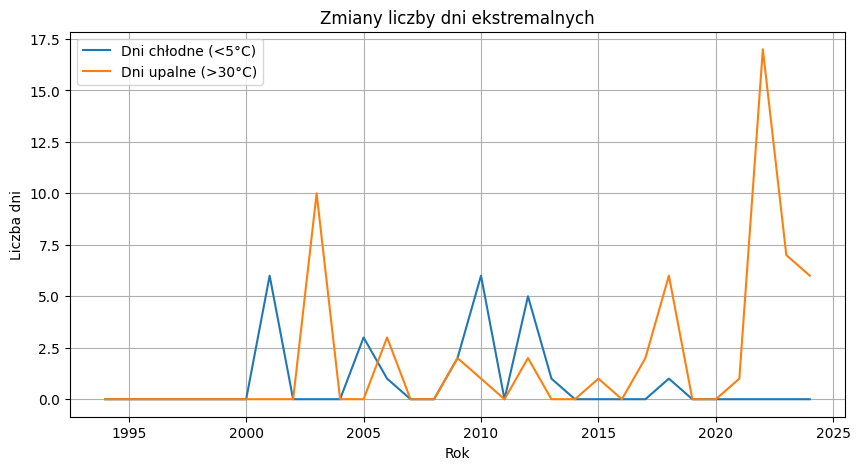

In [71]:
df_climate["cold_day"] = df_climate["t2m"] < 5
df_climate["hot_day"] = df_climate["t2m"] > 30

extreme_days = (
    df_climate
    .groupby("year")[["cold_day", "hot_day"]]
    .sum()
    .reset_index()
)

extreme_days

# Wykres
plt.figure(figsize=(10, 5))
plt.plot(extreme_days["year"], extreme_days["cold_day"], label="Dni chłodne (<5°C)")
plt.plot(extreme_days["year"], extreme_days["hot_day"], label="Dni upalne (>30°C)")
plt.xlabel("Rok")
plt.ylabel("Liczba dni")
plt.title("Zmiany liczby dni ekstremalnych")
plt.legend()
plt.grid(True)
plt.show()



### 4.2) Maksymalna temperatura roczna

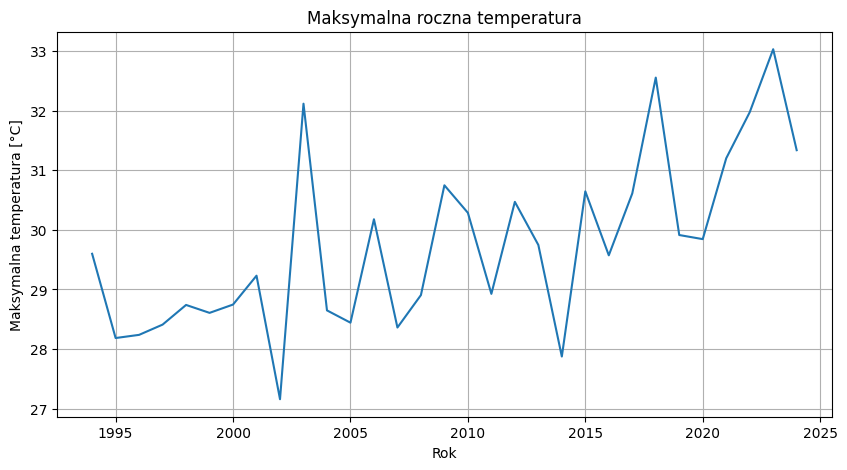

In [72]:
annual_max_temp = (
    df_climate
    .groupby("year")["t2m"]
    .max()
    .reset_index()
)

# Wykres
plt.figure(figsize=(10,5))
plt.plot(annual_max_temp["year"], annual_max_temp["t2m"])
plt.xlabel("Rok")
plt.ylabel("Maksymalna temperatura [°C]")
plt.title("Maksymalna roczna temperatura")
plt.grid(True)
plt.show()

### Część B - ekstrema opadowe

### 4.3) Dni z intensywnym opadem

Dzień z intensywnym opadem: opad > 20 mm/dzień.

10.302207469940173


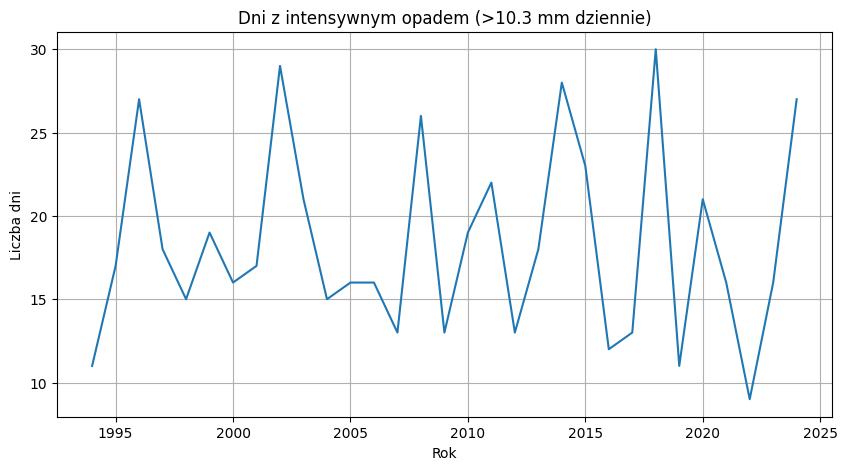

In [84]:
df_climate["tp_mm_day"] = df_climate["tp_mm"]*24
threshold = df_climate["tp_mm_day"].quantile(0.95)
df_climate["heavy_rain"] = df_climate["tp_mm_day"] > threshold
print(threshold)
heavy_rain_days = (
    df_climate
    .groupby("year")["heavy_rain"]
    .sum()
    .reset_index()
)

# Wykres
plt.figure(figsize=(10,5))
plt.plot(annual_max_temp["year"], heavy_rain_days["heavy_rain"])
plt.xlabel("Rok")
plt.ylabel("Liczba dni")
plt.title("Dni z intensywnym opadem (>10.3 mm dziennie)")
plt.grid(True)
plt.show()

### 4.4) Zmienność sezonowa opadów

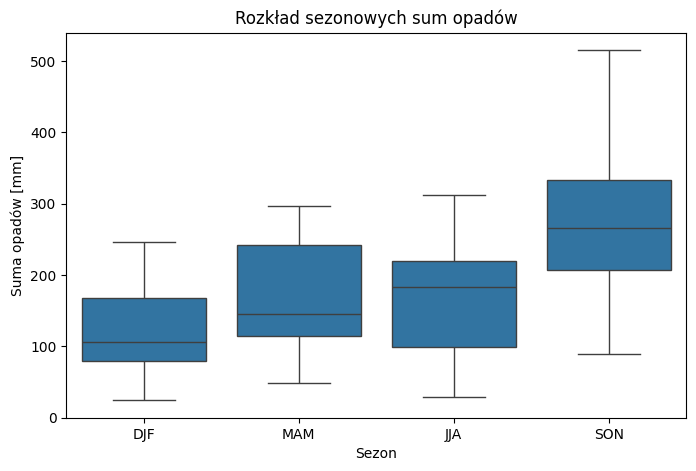

In [83]:
seasonal_precip = (
    df_climate
    .groupby(["year", "season"])["tp_mm_day"]
    .sum()
    .reset_index()
)


plt.figure(figsize=(8,5))
sns.boxplot(
    data=seasonal_precip,
    x="season",
    y="tp_mm_day",
    order=["DJF", "MAM", "JJA", "SON"]
)
plt.xlabel("Sezon")
plt.ylabel("Suma opadów [mm]")
plt.title("Rozkład sezonowych sum opadów")
plt.show()

## Wnioski

Analiza ekstremów klimatycznych w refgionie Barcelony wskazuje na wyraźny wzrost maksymalnych rocznych temperatur oraz rosnącą częstośćdni ekstremalnie ciepłych, przy jednoczesnym spadku liczby dni chłodnych. Wyniki te potwierdzają nasilanie się ekstremów termicznych w analizowanym okresie.

W analizowanym okresie niw striwedzono jednoznacznego trendu wzrostowego rocznych sum opadów, natomiast zastosowanie podejcia percentylowego (0.95) wskazuje na znaczną zmienność częstości dni z intensywnym opadem. Liczba takich zdarzeń wykazuje duże wahania międzyroczne, bez wyraźnego trendu monotonicznego. Jednocześnie analiza sezonowa pokazuje, że najwyższe sumy opadów oraz największą zmienność obserwyje się w sezonie jesiennym, co sugeruje zmianę charakteru opadów - od bardziej równomiernych w czasie do krótkotrwałych, intensywnych epizodów.

## ETAP 5 - Czy techniki ML mogą wspierać analizę zmian klimatu?

### 5.1) Wybór targetu

Opcja A - Średnia temperatura sezonu letniego (JJA)

Opcja B - Liczba dni bardzo gorących (>30°C) w roku

Opcja C - Roczna suma opadów (oszacowana)

### Spróbujmy wytrenować model, który przewiduje średnią tempetaturę sezonu letniego (JJA).

### 5.2) Zbiór cech (features)

Przykładowy zestaw: 
1. temperatura wiosny (MAM);
2. temperatura zimy (DJF);
3. suma promieniowania słonecznego (ssrd);
4. suma promieniowania długofalowego (strd);
5. liczba dni letnich (>20°C);
6. liczba dni gorących (>30°C);
7. opady sezonowe;

### 5.3) Budowa zbioru ML (roczny)

In [75]:
df_ml = (
    df_climate
    .groupby("year")
    .agg({
        "t2m":"mean",
        "tp_mm_day": "sum",
        "ssrd": "sum",
        "strd": "sum",
        "hot_day": "sum",
    })
    .reset_index()
)

In [76]:
target = (
    df_climate[df_climate["season"]=="JJA"]
    .groupby("year")["t2m"]
    .mean()
)

df_ml["target_JJA_temp"] = target.values

### 5.4) Podział danych

In [77]:
train = df_ml[df_ml["year"] <= 2010]
test = df_ml[df_ml["year"] > 2010]

### 5.5) Model ML 

In [78]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X_train = train.drop(columns=["year", "target_JJA_temp"])
y_train = train["target_JJA_temp"]

X_test = test.drop(columns=["year", "target_JJA_temp"])
y_test = test["target_JJA_temp"]

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

r2_score(y_test, pred), mean_absolute_error(y_test, pred)

(0.37269670505024977, 0.603311273711068)

### 5.6) Ważność cech

<Axes: >

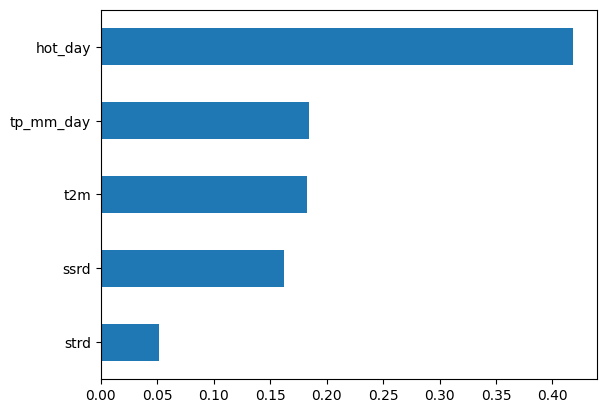

In [79]:
importances = model.feature_importances_
features = X_train.columns

pd.Series(importances, index=features).sort_values().plot.barh()


## Wnioski

Zastosowany model uczenia maszynowego osiągnął współczynnik determinacji R^2 = 0.37 oraz średni błąd bewzględny MAE = 0.6°C. Uzyskane wyniki wskazują, że cechy sezonowe niosą istotną informację o przyszłych wartościach średniej temperatury lata, jednak znaczna część zmienności pozostaje niewyjaśniona. Jest to zgodne z charakterem systemu klimatycznego, który cechuje się wysoką zmiennością naturalną oraz zależnością od czynników niewystępujących w analizowanym zbiorze danych.

[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
    year        t2m
17  2011  23.935305
18  2012  25.568432
19  2013  24.837214
20  2014  24.336153
21  2015  26.065771
22  2016  25.057825
23  2017  26.334583
24  2018  25.909883
25  2019  25.726074
26  2020  25.084488
27  2021  25.460068
28  2022  27.556131
29  2023  26.447342
30  2024  25.748852


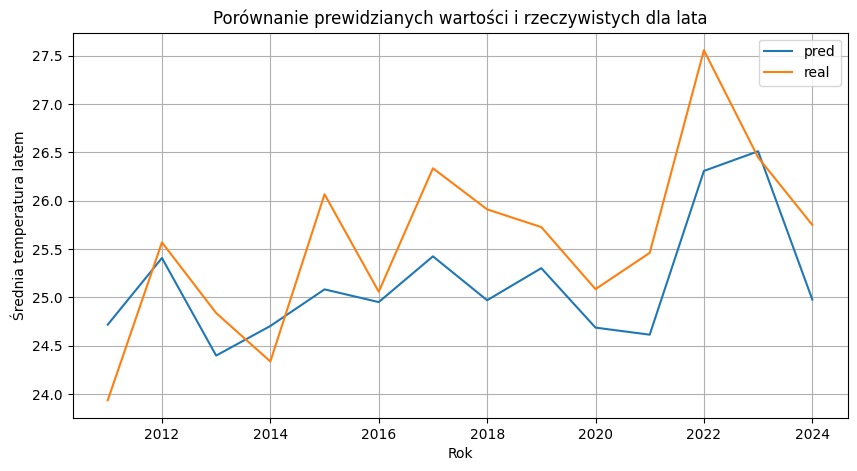

In [80]:
x = []
for i in range(2011, 2025):
    x.append(i)
print(x)

real = (
    df_climate
    .groupby(["year", "season"])["t2m"]
    .mean()
)

real_jja = real.xs("JJA", level="season").reset_index()
real_jja_2011 = real_jja[real_jja["year"] >= 2011]
# real = real[real["seasons"] == "JJA"]
print(real_jja_2011)

      
plt.figure(figsize=(10,5))
plt.plot(x, pred, label="pred")
plt.plot(x, real_jja_2011["t2m"], label="real")
plt.xlabel("Rok")
plt.ylabel("Średnia temperatura latem")
plt.title("Porównanie prewidzianych wartości i rzeczywistych dla lata")
plt.legend()
plt.grid(True)
plt.show()